In [1]:
from _Aplha_n_methods import Alpha_N_calc as an
from _Geometry_methods import Geometry_helper as gh
from _Prettyplt import PrettyPlot as pp

from scipy.optimize import curve_fit
import numpy as np
import openmc
import matplotlib.pyplot as plt

#Loading cross sections
from openmc.data.endf import Evaluation, get_head_record, get_tab1_record
from io import StringIO
from scipy.interpolate import make_interp_spline
from scipy import integrate

pp.makePretty(0.7)

In [2]:
#Getting material 
mats = openmc.Materials.from_xml('materials.xml')

[ 4.313      12.23093939 17.33162121 21.04582121 23.88122727 26.10585051
 27.85298848 29.21289192 30.26910606 31.07253364]


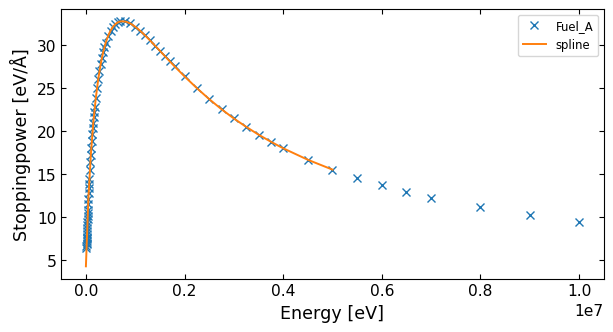

In [3]:
def bethe_tail(E, A, B, C):
    E=np.array(E)
    return A*np.log(B*E)/E + C

def uncertainties_from_cov(popt,cov):
    err=[]
    print('parameters and there error')
    for n in range(len(cov)):
        err.append(np.sqrt(cov[n,n]))
        print(f'{popt[n]:.3g} ± {np.sqrt(cov[n,n]):.1g}')
    return err

def get_stopping_power_spline(mat,k=5,E_min=1e4,E_max=1e7,new_file=True):
    energies,stopping_powers = an.SR_file_write_and_read(mat,E_min=E_min,E_max=E_max,new_file=new_file)
    while k>0:    
        try:    
            spline = make_interp_spline(energies,stopping_powers,k=k,bc_type='periodic')
            break
        except:
            k-=1
            if k==1:
                spline = make_interp_spline(energies,stopping_powers,k=k)
    return spline
def get_spline_data(spline,xs,extrapolate = False,non_negative=False):
    spline_with_nan = spline(xs, extrapolate=extrapolate)
    spline_data = np.nan_to_num(spline_with_nan,nan=0.00)

    if non_negative:
        spline_data = np.clip(spline_data,0,None) #sets all negative values to zero

    return spline_data

fuel_name= 'Fuel_A'
mat = gh.get_material_by_name(fuel_name,mats)
E_min=1e4
E_max=5e6
energies,stopping_powers = an.SR_file_write_and_read(mat,E_min=E_min,E_max=E_max,new_file=False)

fig,ax = plt.subplots()
ax.plot(energies,stopping_powers,'x',label=fuel_name)
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('Stoppingpower [eV/Å]')    
if E_min>5e5:
    popt, cov = curve_fit(bethe_tail,energies, stopping_powers,p0=[ 3.22e+07, 2.8e-06, -1.44])
    stopping_powers_fit = bethe_tail(energies, *popt)
    ax.plot(energies,stopping_powers_fit,label='fit')
    pp.plot_residuals(energies,stopping_powers,bethe_tail,energy_lin,popt,xlabel='Energy [eV]',ylabel='Stoppingpower [eV/Å]',title='Stopping power')

    err = uncertainties_from_cov(popt,cov)

energy_lin = np.linspace(0,5e6,100)

stop_spline = get_stopping_power_spline(mat,E_min=E_min,E_max=E_max,new_file=False)
stop_spline_data = get_spline_data(stop_spline,energy_lin,extrapolate = True)

ax.plot(energy_lin,stop_spline_data,label = 'spline')

ax.legend()
print(stop_spline_data[0:10])

pp.savefig('stoppingpower_spline')


1e6


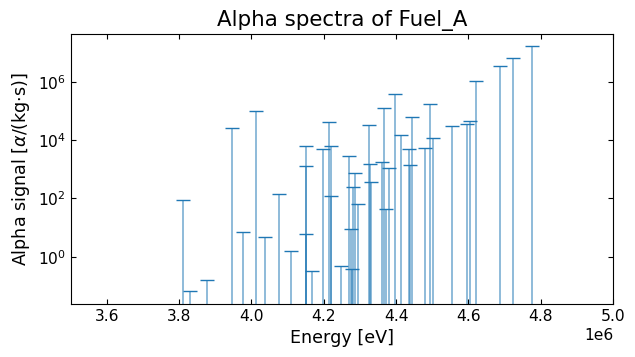

In [4]:
#Introducing alpha spectra and make sure to it is possible to calculate with the to data sets
alpha_decays, mass, nuclide_amount = an.alpha_decay_values_from_material(mat)
#alpha_spectra,energies = an.energy_spectra_gaussian(alpha_decays,x=None)

alpha_spectra = []
alpha_energies = []

for name, a_activities, a_energies,energy_devs,_  in alpha_decays:
    alpha_spectra.extend(a_activities)
    alpha_energies.extend(a_energies)
#sorting energies
alpha_spectra = [a/mass for _,a in sorted(zip(alpha_energies,alpha_spectra))]
alpha_energies = sorted(alpha_energies)

fig, ax = plt.subplots()
#ax.plot(energies,alpha_spectra)

line, = ax.plot(alpha_energies, alpha_spectra, "_", label=r'$\alpha$',ms=10)
ax.vlines(alpha_energies,[0]*len(alpha_energies),alpha_spectra,line.get_color(),alpha=0.5)
ax.semilogy()
ax.set_title(f'Alpha spectra of {mat.name}')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel(r'Alpha signal [$\alpha$/(kg$\cdot$s)]')
ax.set_xlim(3.5e6,5e6)

pp.savefig(f'Alpha_spectra_{mat.name}')


mt alpha reactions: 4=n', 16=2n, 17=3n, 22=n+a
23=n+3a, 24=2n+a, 25=3n+a, 28=n+p and 29=n+2a


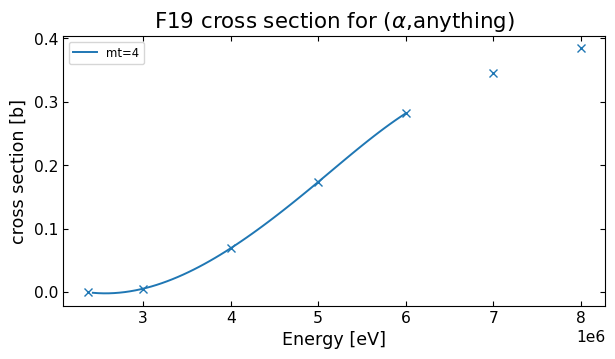

In [5]:

#Also possible with .tendl files seems jendl is better but tendl is more exstensive

def get_crosssection_spline(nuc_name, mt,k=1, xs=None, x_min=2e6, x_max=8e6):
    #Getting data
    symbol,Z,A = an.isolate_atomic_symbol(nuc_name)
    ev = Evaluation(f"/root/TENDL-a/a-{symbol}{A}.tendl")
    
    mf=3 #Reaction cross sections
    try:
        endf_output = StringIO(ev.section[mf,mt])
    except:
        #print(f'mt={mt} does not exist')
        return None,None, None
    head = get_head_record(endf_output)
    params, tab = get_tab1_record(endf_output)
    #print('energy',tab.x)   # energies in eV
    #print('cross section',tab.y)   # cross sections in barns

    #Removing data under x_min, over x_max and duplicates 
    mask = (tab.x >= x_min) & (tab.x <= x_max)
    tab.x = tab.x[mask]
    tab.y = tab.y[mask]
    if len(tab.x) ==0:
        #print(f'no data between {x_min} eV and {x_max} eV')
        return None,None,None
    tab.x, idx = np.unique(tab.x, return_index=True)
    tab.y = tab.y[idx]

    if xs is None:
        xs = np.linspace(min(tab.x),max(tab.x),int(1e4))
    while k>0:    
        try:    
            spline = make_interp_spline(tab.x,tab.y,k=k)
            break
        except:
            k-=1
            if k==1:
                spline = make_interp_spline(tab.x,tab.y,k=k)
    return spline, tab, xs

def get_crossection_from_isotope(nuc_name,k=1,xs=None, x_min=0, x_max=8e6, plot=True,print_no_data=False):
    splines={}
    tabs={}
    failed_mts = []
    if plot:
        fig,ax = plt.subplots()
        ax.set_title(rf'{nuc_name} cross section for ($\alpha$,anything)')
        ax.set_xlabel('Energy [eV]')
        ax.set_ylabel(r'cross section [b]')
    
    for mt in np.array([4,16,17,22,23,24,25,28,29]):
        mt= int(mt)
        spline, tab ,xs = get_crosssection_spline(nuc_name,mt,k,xs,x_min,x_max)
        
        if spline != None:
            splines[mt]=spline
            tabs[mt]=tab
            if plot:
                ax.plot(tab.x,tab.y,'x-',label=f'mt={mt}')
                ax.plot(xs,spline(xs))
        else:
            failed_mts.append(mt)
    if len(failed_mts)>0 and print_no_data:  
        print(f'In {nuc_name} following mts had no data',failed_mts)
    if plot:
        ax.legend()
    return splines,tabs
    
#splines = get_crossection_from_material('Be009',x_max=9e7)
nuc_cross_splines={}
nuc_cross_tabs={}
for nuc in mat.nuclides:
    splines,tabs = get_crossection_from_isotope(nuc.name,k=3,x_max=8e6,plot=False)
    nuc_cross_splines[nuc.name]=splines
    nuc_cross_tabs[nuc.name]=tabs
print('mt alpha reactions: 4=n\', 16=2n, 17=3n, 22=n+a\n23=n+3a, 24=2n+a, 25=3n+a, 28=n+p and 29=n+2a')  
nuc_name='F19'
xs=np.linspace(0,6e6,100)

fig,ax = plt.subplots()
ax.set_title(rf'{nuc_name} cross section for ($\alpha$,anything)')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel(r'cross section [b]')
for mt in nuc_cross_splines[nuc_name]:
    spline = nuc_cross_splines[nuc_name][mt]
    tab = nuc_cross_tabs[nuc_name][mt]
    dat_plot,=ax.plot(tab.x,tab.y,'x')
    ax.plot(xs,spline(xs, extrapolate=False),label=f'mt={mt}',color=dat_plot.get_color())

ax.legend()
pp.savefig('Be9_crossection')

1e6


/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)


 Alpha per second: 2.85e+07
n/(kg*s) from Fuel_A is 211.5 with 1e+02 points giving 7.42 n/10^6 a
for 4.77 MeV the neutrons pr alpha is 7.77
Fuel_A mass in kg: 1.64e+03 which gives 3.47e+05 neutrons/s

1e6
 Alpha per second: 1.63e+07
n/(kg*s) from Fuel_B is 138.6 with 1e+02 points giving 8.52 n/10^6 a
for 4.77 MeV the neutrons pr alpha is 8.76
Fuel_B mass in kg: 1.53e+03 which gives 2.11e+05 neutrons/s

1e6
 Alpha per second: 1.71e+07
n/(kg*s) from Fuel_C is 143.3 with 1e+02 points giving 8.37 n/10^6 a
for 4.77 MeV the neutrons pr alpha is 8.68
Fuel_C mass in kg: 1.62e+03 which gives 2.32e+05 neutrons/s



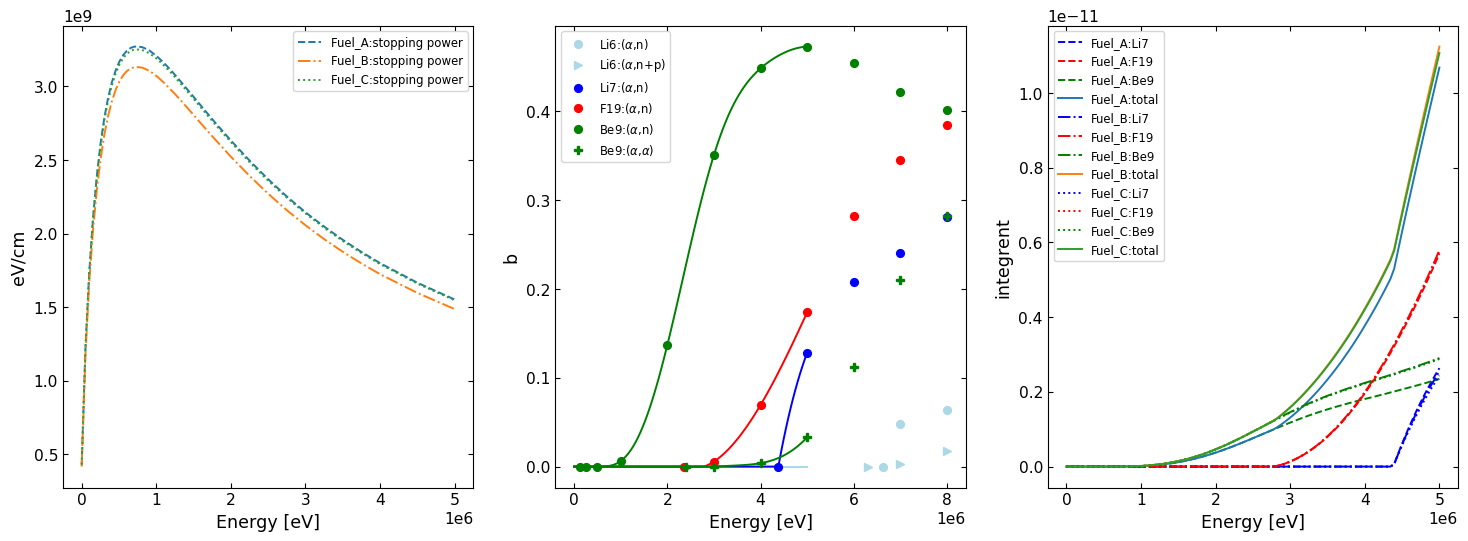

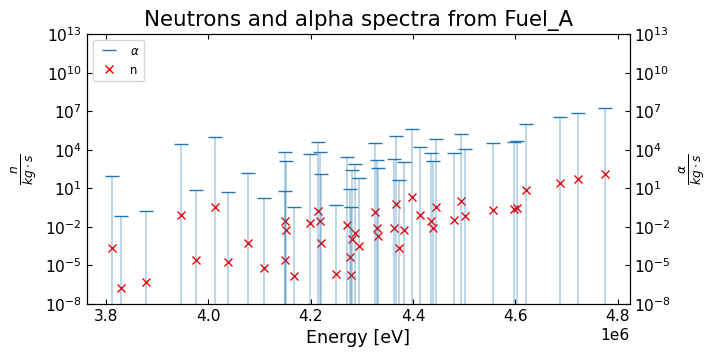

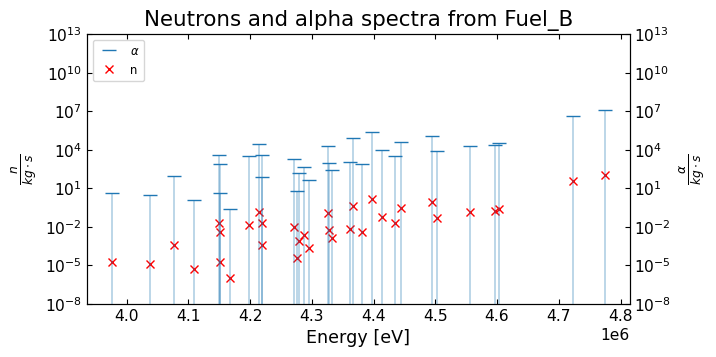

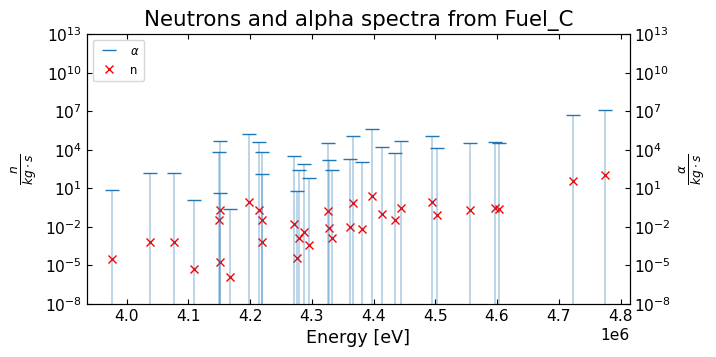

In [6]:
#Making the basic integral

def neutrons_from_material(mat,E_min=0,E_max=6e6,nr_points=1000,
                           plot_result=True, plot_parts=True, plot_crosssections=True,
                          use_gaussian_spectra=False,ORNL_numbers=False):
    #Getting data
    energies = np.linspace(E_min,E_max,nr_points)
    
    mat_dens = mat.get_nuclide_atom_densities() #returns nuclide densities in atom/b-cm

    #Stopping power splines
    stopping_power_spline = get_stopping_power_spline(mat,E_min=1e4,E_max=1e7,new_file=False)
    stopping_powers=get_spline_data(stopping_power_spline,energies, extrapolate=True)
    stopping_powers = np.array(stopping_powers)*1e8 #Converting from eV/Å to eV/cm
    
    #Alpha spectrum
    alpha_decays, mass,nuclide_amount = an.alpha_decay_values_from_material(mat)
    if use_gaussian_spectra:
        alpha_spectra,energies = an.energy_spectra_gaussian(alpha_decays,x=energies)
    elif ORNL_numbers:
        mass_kg = mat.density*707921.1677922/1000 #mass for 25 ft^3 fuel
        alpha_energies  = [4.15e6, 4.19e6, 4.20e6, 4.40e6, 4.45e6, 4.47e6, 4.49e6, 4.58e6, 4.72e6, 4.77e6]
        alpha_sources = {"Fuel_A": [0.41e6, 1.40e6, 0.86e8, 0.65e8, 5.01e8, 2.13e8, 17.7e8, 1.85e10, 1.83e8, 4.74e10],
                         "Fuel_B": [0.25e6, 0.86e6, 0.53e8, 0.40e8, 3.06e8, 1.30e8, 10.8e8, 1.13e10, 1.12e8, 2.90e10],
                         "Fuel_C": [0.13e6, 0.45e8, 0.85e8, 0.63e8, 3.92e8, 2.09e8, 17.3e8, 1.45e10, 1.44e8, 3.71e10]}
        alpha_spectra = [a/mass_kg for a in alpha_sources[mat.name]]
    else:
        alpha_spectra = []
        alpha_energies = []
        for name, a_activities, a_energies,energy_devs,_  in alpha_decays:
            alpha_spectra.extend(a_activities)
            alpha_energies.extend(a_energies)
        #sorting energies
        alpha_spectra = [a/mass for _,a in sorted(zip(alpha_energies,alpha_spectra))]
        alpha_energies = sorted(alpha_energies)
    
    if plot_parts:
        isotope_color_lib = {'Li6':'lightblue','Li7':'b','F19':'r','Be9':'g'}
        mt_to_markers = {4: 'o',11: 's',16: '^',17: 'v',18: 'D',22: 'P',23: 'X',24: '*',
                         25: '<',28: '>',29: 'p',30: 'h',32: 'H',33: 'd',34: '8',35: '+',}
        mt_to_reaction = {4:  r'($\alpha$,n)', 11: r'($\alpha$,2n+d)',16: r'($\alpha$,2n)',
                        17: r'($\alpha$,3n)',18: r'($\alpha$,f)',22: r'($\alpha$,$\alpha$)',
                        23: r'($\alpha$,n+3$\alpha$)',24: r'($\alpha$,2n+$\alpha$)',
                        25: r'($\alpha$,3n+$\alpha$)',28: r'($\alpha$,n+p)',29: r'($\alpha$,n+2$\alpha$)',
                        30: r'($\alpha$,2n+2$\alpha$)',32: r'($\alpha$,n+d)',33: r'($\alpha$,n+t)',
                        34: r'($\alpha$,n+h)',35: r'($\alpha$,n+d+2$\alpha$)',
                       }
        fuel_name_to_linetype = {'Fuel_A':'dashed','Fuel_B':'dashdot','Fuel_C':'dotted'}
        #fig, ax = plt.subplots(1,3,figsize=(18,6))

    total_integrent = np.zeros(nr_points)
    
    for nuc in mat.nuclides:
        #Getting crosssections
        cross_splines,tab = get_crossection_from_isotope(nuc.name,k=5,x_max=8e6,plot=False)
        total_crosssection = np.zeros(nr_points)
        for mt in cross_splines:
            spline_data = get_spline_data(cross_splines[mt],energies, extrapolate=False,non_negative=True)
            
            if mt in [4,22,23,28,29]: #(a,n+anything)
                total_crosssection += spline_data
                
            elif mt in [11,16,24,30]: #(a,2n+anything)
                total_crosssection += 2*spline_data
                
            elif mt in [17,25]: #(a,3n+anything) for up to mt=30
                total_crosssection += 3*spline_data
            else:
                print(f'reaction with mt={mt} is not know')
                
            if plot_crosssections and np.sum(tab[mt].y)>1e-3 and plot_parts:
                data,=ax[1].plot(tab[mt].x,tab[mt].y,f'{mt_to_markers[mt]}',label=f'{nuc.name}:{mt_to_reaction[mt]}',color=isotope_color_lib[nuc.name])
                ax[1].plot(energies,spline_data,color=data.get_color())

        
        #Making integrent
        target_density = mat_dens[nuc.name] #atom/b-cm 
        
        #total_crosssection is in barns
        #stopping powers is in eV/cm
        
        integrent = target_density*total_crosssection/stopping_powers
        if np.sum(total_crosssection)>0 and plot_parts:
            ax[2].plot(energies,integrent,label=f'{mat.name}:{nuc.name}',color=isotope_color_lib[nuc.name],linestyle=f'{fuel_name_to_linetype[mat.name]}')
            #print(f'target_density for {nuc.name} in {mat.name} = {target_density:.3g} and integrent sum {sum(integrent):.3g}')

        #print('integrent',sum(integrent),nuc.name)
        
        total_integrent += integrent

    #dx=(E_max-E_min)/nr_points
    neutrons_total = 0
    neutrons_added = []
    integrent_spline = make_interp_spline(energies,total_integrent,k=5)
    
    for E_a,alpha in zip(alpha_energies,alpha_spectra):
        result,err = integrate.quad(integrent_spline,0,E_a)
        neutrons = alpha*result
        neutrons_total +=neutrons
        neutrons_added.append(neutrons)
        
    if plot_parts:
        ax[0].plot(energies,stopping_powers,label=f'{mat.name}:stopping power',linestyle=f'{fuel_name_to_linetype[mat.name]}')
        #ax[1].plot(energies,total_crosssection,label='cross_section')
        ax[2].plot(energies,integrent_spline(energies),label=f'{mat.name}:total')
        #ax[2].semilogy()
        #ax[2].set_xlim(3.7e6,5e6)
        ax[0].set_ylabel('eV/cm')
        ax[1].set_ylabel('b')
        ax[2].set_ylabel('integrent')
        for a in ax:
            a.set_xlabel('Energy [eV]')
            a.legend()
            #ax1 = a.twinx()
            if use_gaussian_spectra:
                ax1.plot(energies,alpha_spectra,label='spectra',color='k',alpha=0.3)
            #else:
                #line, =ax1.plot(alpha_energies, alpha_spectra, "_", label=name,ms=10)
                #ax1.vlines(alpha_energies,[0]*len(alpha_energies),alpha_spectra,line.get_color(),alpha=0.3)
            #ax1.semilogy()
            #ax1.set_ylim(1e-2,1e7)
            #ax1.set_ylabel(r'$\alpha$/s')
        
        pp.savefig(f'part_for_integral_{mat.name}')

        #Ploting result
        fig2,ax2 = plt.subplots()
        ax3=ax2.twinx()
    
        
        if use_gaussian_spectra:
            ax3.plot(energies,alpha_spectra,label='spectra',color='k',lw=2,alpha=0.3)
            ax2.plot(energies,neutrons_added,'x',label='n')
        else:
            line, = ax3.plot(alpha_energies, alpha_spectra, "_", label=r'$\alpha$',ms=10)
            ax3.vlines(alpha_energies,[0]*len(alpha_energies),alpha_spectra,line.get_color(),alpha=0.3)
            line2, = ax2.plot(alpha_energies,neutrons_added,'rx',label='n')
        
        ax2.set_title(f'Neutrons and alpha spectra from {mat.name}')
        ax2.set_xlabel('Energy [eV]')
        ax2.set_ylabel(r'$\frac{n}{kg\cdot s}$')
        ax3.set_ylabel(r'$\frac{\alpha}{kg\cdot s}$')
        ax2.legend([line, line2],[line.get_label(), line2.get_label()],loc='upper left')
    
        
        ax2.semilogy()
        ax3.semilogy()
        
        #ax2.set_xlim(3.5e6,5e6)
        ax2.set_ylim(1e-8,1e13)
        ax3.set_ylim(1e-8,1e13)
        
        pp.savefig(f'integral_{mat.name}')
    if use_gaussian_spectra:
        neutrons_total_integral = integrate.simpson(neutrons_added,alpha_energies)
        print('Number of alpha',integrate.simpson(alpha_spectra,energies))
        print(f'Number of neutrons pr second from {mat.name} using integral is {neutrons_total_integral:.5g}')
    total_alphas = sum(alpha_spectra)
    print(f' Alpha per second: {total_alphas:.3g}')
    neutrons_per_alpha = neutrons_total*(1e6/total_alphas)
    print(f'n/(kg*s) from {mat.name} is {neutrons_total:.4g} with {nr_points:.2g} points giving {neutrons_per_alpha:.3g} n/10^6 a')
    print(f'for {alpha_energies[-1]/1e6:.3g} MeV the neutrons pr alpha is {neutrons_added[-1]/alpha_spectra[-1]*1e6:.3g}')
    return neutrons_total, total_alphas

    
fig, ax = plt.subplots(1,3,figsize=(18,6))
points_power = 2
fuel_name= 'Fuel_A'
mat = gh.get_material_by_name(fuel_name,mats)
neutrons,_ = neutrons_from_material(mat,E_max=5e6,nr_points=10**points_power,plot_parts=True)
mass_kg = mat.density*707921.1677922/1000
print(f'{mat.name} mass in kg: {mass_kg:.3g} which gives {neutrons*mass_kg:.3g} neutrons/s\n')

fuel_name= 'Fuel_B'
mat = gh.get_material_by_name(fuel_name,mats)
neutrons,_ = neutrons_from_material(mat,E_max=5e6,nr_points=10**points_power,plot_parts=True,plot_crosssections=False)
mass_kg = mat.density*707921.1677922/1000
print(f'{mat.name} mass in kg: {mass_kg:.3g} which gives {neutrons*mass_kg:.3g} neutrons/s\n')

fuel_name= 'Fuel_C'
mat = gh.get_material_by_name(fuel_name,mats)
neutrons,_ = neutrons_from_material(mat,E_max=5e6,nr_points=10**points_power,plot_parts=True,plot_crosssections=False)
mass_kg = mat.density*707921.1677922/1000
print(f'{mat.name} mass in kg: {mass_kg:.3g} which gives {neutrons*mass_kg:.3g} neutrons/s\n')

#pp.savefig('all_fuel_comp',figure=fig)

In [7]:
def deviation_calc(x,y):
    return abs((x-y)/x*100)

print(f'{deviation_calc(7.03,7.77):.3g} %')
print(f'{deviation_calc(7.78,8.76):.3g} %')
print(f'{deviation_calc(7.62,8.68):.3g} %')
fuels = ['Fuel_A','Fuel_B','Fuel_C']

for fuel_name in fuels:
    mat = gh.get_material_by_name(fuel_name,mats)
    print(f'{mat.name} mass in kg: {mat.density*707921.1677922/1000:.3g}  ')

print(f'{deviation_calc(4.67,3.47):.3g} %')
print(f'{deviation_calc(3.17,2.11):.3g} %')
print(f'{deviation_calc(3.99,2.32):.3g} %')

10.5 %
12.6 %
13.9 %
Fuel_A mass in kg: 1.64e+03  
Fuel_B mass in kg: 1.53e+03  
Fuel_C mass in kg: 1.62e+03  
25.7 %
33.4 %
41.9 %


In [8]:
points_power = 3
plot=False
ORNL_neutrons_lib = {'Fuel_A':4.67e5,'Fuel_B':3.17e5,'Fuel_C':3.99e5}
if plot:
    fig, ax = plt.subplots(1,3,figsize=(18,6))

for fuel_name in fuels:
    mat = gh.get_material_by_name(fuel_name,mats)
    mass_kg = mat.density*707921.1677922/1000
    neutrons, alphas = neutrons_from_material(mat,E_max=5e6,nr_points=10**points_power,plot_parts=plot,ORNL_numbers=False)
    print(f'{mat.name} mass in kg: {mass_kg:.3g} which gives {neutrons*mass_kg:.3g} neutrons/s')
    print(' ORNL:')
    neutrons_ORNL,alphas_ORNL = neutrons_from_material(mat,E_max=5e6,nr_points=10**points_power,plot_parts=plot,ORNL_numbers=True)
    print(f'{mat.name} mass in kg: {mass_kg:.3g} which gives {neutrons_ORNL*mass_kg:.3g} neutrons/s')
    print(f'\nDevviations: Alpha per second {deviation_calc(alphas_ORNL,alphas):.3g} %,n/s from ORNL alpha spectrum {deviation_calc(ORNL_neutrons_lib[mat.name],neutrons_ORNL*mass_kg):.3g} %,n/s from own alpha spectrum {deviation_calc(ORNL_neutrons_lib[mat.name],neutrons*mass_kg):.3g} %\n')



1e6
 Alpha per second: 2.85e+07
n/(kg*s) from Fuel_A is 211.5 with 1e+03 points giving 7.42 n/10^6 a
for 4.77 MeV the neutrons pr alpha is 7.77
Fuel_A mass in kg: 1.64e+03 which gives 3.47e+05 neutrons/s
 ORNL:
1e6
 Alpha per second: 4.19e+07
n/(kg*s) from Fuel_A is 303.6 with 1e+03 points giving 7.24 n/10^6 a
for 4.77 MeV the neutrons pr alpha is 7.73
Fuel_A mass in kg: 1.64e+03 which gives 4.97e+05 neutrons/s

Devviations: Alpha per second 32.1 %,n/s from ORNL alpha spectrum 6.52 %,n/s from own alpha spectrum 25.8 %

1e6
 Alpha per second: 1.63e+07
n/(kg*s) from Fuel_B is 138.6 with 1e+03 points giving 8.52 n/10^6 a
for 4.77 MeV the neutrons pr alpha is 8.76
Fuel_B mass in kg: 1.53e+03 which gives 2.11e+05 neutrons/s
 ORNL:
1e6
 Alpha per second: 2.76e+07
n/(kg*s) from Fuel_B is 225.7 with 1e+03 points giving 8.19 n/10^6 a
for 4.77 MeV the neutrons pr alpha is 8.71
Fuel_B mass in kg: 1.53e+03 which gives 3.44e+05 neutrons/s

Devviations: Alpha per second 41 %,n/s from ORNL alpha spec